# flock_sim benchmarks

Repeatable timing of the jitted `update_step`, anchored to the config used in
`flock_field.ipynb`. Run all cells; each sweep recompiles per point (static args),
so expect ~1–2 minutes total on CPU.

Timings are median wall time over `REPEATS` calls after warmup, with
`block_until_ready` so JAX's async dispatch doesn't lie to us. Error bars show
min–max.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/evanreierson/flock-field/blob/main/benchmark.ipynb)

To benchmark on TPU: open in Colab, pick a TPU runtime
(Runtime → Change runtime type → TPU), and run all cells. The setup cell
below clones the repo and installs deps; the first code cell prints which
backend JAX is using, so confirm it says `tpu` before reading the numbers.

In [ ]:
# Colab setup: clone the repo and install deps not preinstalled there.
# No-op when running locally (use `uv sync` instead).
import pathlib
import sys

if "google.colab" in sys.modules:
    if not pathlib.Path("/content/flock-field").exists():
        !git clone -q https://github.com/evanreierson/flock-field.git /content/flock-field
    %cd /content/flock-field
    %pip install -q beartype chex jaxtyping

In [1]:
import statistics
import time

import jax
import matplotlib.pyplot as plt
import numpy as np

from flock_sim import (
    alignment_field,
    boundary_field,
    cohesion_field,
    default_kernel_radius,
    initialize_flock,
    make_update_step,
    noise_field,
    sample_field_bilinear,
    separation_field,
)

# Baseline config, matching flock_field.ipynb
BASE = dict(
    dt=0.016,
    speed=1.0,
    separation_strength=0.5,
    turn_rate=0.3,
    sigma=0.09,
    cohesion_strength=0.10,
    cohesion_sigma=0.15,
    alignment_strength=0.05,
    alignment_sigma=0.15,
    boundary_margin=0.2,
    boundary_strength=8.0,
    noise_strength=0.3,
    noise_grid_size=1,
    noise_temporal_rate=0.025,
)
BASE_POPULATION = 200
BASE_GRID = 128
WARMUP = 4
REPEATS = 15
FRAME_BUDGET_MS = 1000 / 60

print(f"jax {jax.__version__}, backend: {jax.default_backend()}")


def bench(fn, *args, warmup=WARMUP, repeats=REPEATS):
    """Median wall time in ms (plus min/max); blocks on the result."""
    for _ in range(warmup):
        jax.block_until_ready(fn(*args))
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        times.append((time.perf_counter() - t0) * 1e3)
    return statistics.median(times), min(times), max(times)


def make_flock(population, seed=10):
    return initialize_flock(jax.random.key(seed), population)


def sweep_update_step(values, population=None, grid=None, config=None):
    """Bench the full jitted update step across one swept parameter.

    Exactly one of population/grid/config should be a callable of the swept value;
    the others stay at baseline.
    """
    medians, lows, highs = [], [], []
    for v in values:
        pop = population(v) if callable(population) else BASE_POPULATION
        g = grid(v) if callable(grid) else BASE_GRID
        cfg = config(v) if callable(config) else dict(BASE)
        step = make_update_step(simulation_grid_size=g, **cfg)
        med, lo, hi = bench(step, make_flock(pop))
        medians.append(med)
        lows.append(lo)
        highs.append(hi)
        print(f"  {v}: {med:.3f} ms")
    return np.array(medians), np.array(lows), np.array(highs)


def fit_exponent(x, y):
    """Least-squares slope of log(y) vs log(x): the power-law exponent."""
    return np.polyfit(np.log(np.asarray(x, float)), np.log(y), 1)[0]


# Chart chrome
INK = "#0b0b0b"
MUTED = "#898781"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
BLUE = "#2a78d6"
SURFACE = "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": MUTED,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlecolor": INK,
    "font.family": "sans-serif",
    "figure.dpi": 110,
})


def scaling_plot(x, med, lo, hi, xlabel, title, exponent=None, log=True,
                 budget_line=True):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.errorbar(
        x, med, yerr=[med - lo, hi - med],
        color=BLUE, linewidth=2, marker="o", markersize=6,
        elinewidth=1, capsize=2, ecolor=AXIS, zorder=3,
    )
    if log:
        ax.set_xscale("log")
        ax.set_yscale("log")
    if budget_line:
        ax.axhline(FRAME_BUDGET_MS, color=AXIS, linewidth=1, linestyle="--")
        ax.annotate("60 fps budget (16.7 ms)", (x[0], FRAME_BUDGET_MS),
                    textcoords="offset points", xytext=(0, 5),
                    fontsize=9, color=MUTED)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("step time (ms)")
    label = title if exponent is None else f"{title} — fitted exponent {exponent:.2f}"
    ax.set_title(label, fontsize=11, loc="left")
    fig.tight_layout()
    return fig, ax

jax 0.10.2, backend: cpu


## Baseline: full update step at the notebook config

In [2]:
flock = make_flock(BASE_POPULATION)
step = make_update_step(simulation_grid_size=BASE_GRID, **BASE)

t0 = time.perf_counter()
jax.block_until_ready(step(flock))
print(f"first call (compile + run): {(time.perf_counter() - t0) * 1e3:.1f} ms")

med, lo, hi = bench(step, flock, warmup=5, repeats=100)
print(f"steady state: {med:.3f} ms  (min {lo:.3f}, max {hi:.3f})")
print(f"-> {1e3 / med:.0f} steps/s; 60 fps budget is {FRAME_BUDGET_MS:.1f} ms")

first call (compile + run): 142.4 ms
steady state: 3.096 ms  (min 2.848, max 14.853)
-> 323 steps/s; 60 fps budget is 16.7 ms


## Component breakdown

Each field jitted and timed alone. These sum to more than the full step —
XLA fuses across components when compiled together — so read the shares,
not the absolute total.

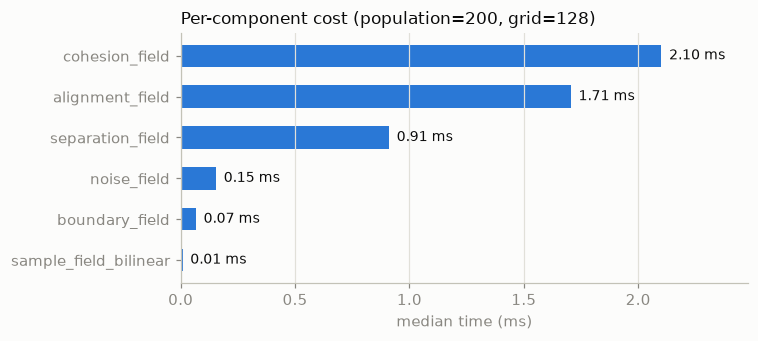

separation: kernel radius 18 -> 1369 cells splatted per bird
cohesion: kernel radius 29 -> 3481 cells splatted per bird
alignment: kernel radius 29 -> 3481 cells splatted per bird


In [3]:
g = BASE_GRID
empty_field = jax.numpy.zeros((g, g, 2), dtype=flock.positions.dtype)

components = {
    "cohesion_field": (jax.jit(lambda f: cohesion_field(
        flock=f, simulation_grid_size=g,
        sigma=BASE["cohesion_sigma"], strength=BASE["cohesion_strength"])), (flock,)),
    "alignment_field": (jax.jit(lambda f: alignment_field(
        flock=f, simulation_grid_size=g,
        sigma=BASE["alignment_sigma"], strength=BASE["alignment_strength"])), (flock,)),
    "separation_field": (jax.jit(lambda f: separation_field(
        flock=f, simulation_grid_size=g,
        sigma=BASE["sigma"], strength=BASE["separation_strength"])), (flock,)),
    "noise_field": (jax.jit(lambda gen: noise_field(
        generation=gen, simulation_grid_size=g, strength=BASE["noise_strength"],
        noise_grid_size=BASE["noise_grid_size"],
        temporal_rate=BASE["noise_temporal_rate"])), (flock.generation,)),
    "boundary_field": (jax.jit(lambda: boundary_field(
        simulation_grid_size=g, margin=BASE["boundary_margin"],
        strength=BASE["boundary_strength"])), ()),
    "sample_field_bilinear": (jax.jit(sample_field_bilinear),
                              (empty_field, flock.positions)),
}

component_ms = {}
for name, (fn, args) in components.items():
    component_ms[name] = bench(fn, *args)[0]

order = sorted(component_ms, key=component_ms.get)
values = [component_ms[n] for n in order]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(order, values, height=0.55, color=BLUE)
for i, v in enumerate(values):
    ax.annotate(f"{v:.2f} ms", (v, i), textcoords="offset points",
                xytext=(5, 0), va="center", fontsize=9, color=INK)
ax.set_xlim(0, max(values) * 1.18)
ax.set_xlabel("median time (ms)")
ax.set_title(
    f"Per-component cost (population={BASE_POPULATION}, grid={BASE_GRID})",
    fontsize=11, loc="left")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

for s, name in (("sigma", "separation"), ("cohesion_sigma", "cohesion"),
                ("alignment_sigma", "alignment")):
    r = default_kernel_radius(BASE[s], BASE_GRID)
    print(f"{name}: kernel radius {r} -> {(2 * r + 1) ** 2} cells splatted per bird")

## Scaling with population N

The splat is dense per bird — O(N × kernel cells) — so this should be linear
(exponent ≈ 1 on the log–log fit).

  50: 0.952 ms
  100: 1.725 ms
  200: 3.060 ms
  500: 7.510 ms
  1000: 14.404 ms
  2000: 30.882 ms
  5000: 67.118 ms
  10000: 136.064 ms


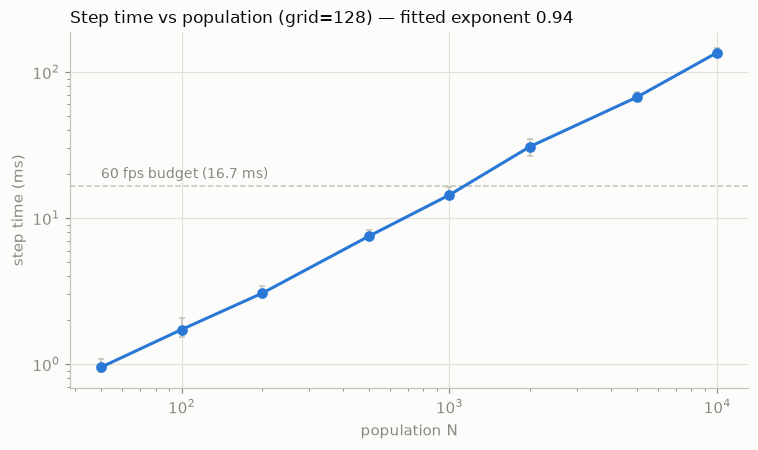

In [4]:
populations = np.array([50, 100, 200, 500, 1000, 2000, 5000, 10000])
n_med, n_lo, n_hi = sweep_update_step(populations, population=lambda n: n)

fig, ax = scaling_plot(
    populations, n_med, n_lo, n_hi,
    xlabel="population N",
    title=f"Step time vs population (grid={BASE_GRID})",
    exponent=fit_exponent(populations, n_med),
)
plt.show()

## Scaling with grid size g

`default_kernel_radius` converts sigma to cells, so the kernel window grows with
the grid and the splat cost scales like g² for fixed sigma (once the window
dominates fixed overheads).

  32: 0.517 ms
  48: 0.707 ms
  64: 0.958 ms
  96: 1.865 ms
  128: 3.010 ms
  192: 6.448 ms
  256: 11.466 ms
  384: 26.078 ms
  512: 42.436 ms


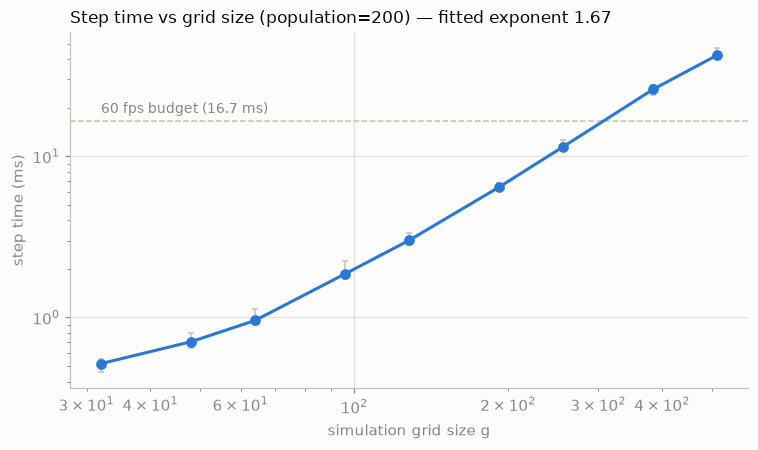

In [5]:
grids = np.array([32, 48, 64, 96, 128, 192, 256, 384, 512])
g_med, g_lo, g_hi = sweep_update_step(grids, grid=lambda g: int(g))

fig, ax = scaling_plot(
    grids, g_med, g_lo, g_hi,
    xlabel="simulation grid size g",
    title=f"Step time vs grid size (population={BASE_POPULATION})",
    exponent=fit_exponent(grids, g_med),
)
plt.show()

## Scaling with sigma

All three interaction sigmas (`sigma`, `cohesion_sigma`, `alignment_sigma`)
scaled by a common multiplier around the baseline. Kernel radius is 3 sigma in
cells, so splat cost should go like sigma² (exponent ≈ 2).

  0.5: 1.074 ms
  0.75: 1.911 ms
  1.0: 3.123 ms
  1.25: 4.792 ms
  1.5: 6.378 ms
  2.0: 12.101 ms


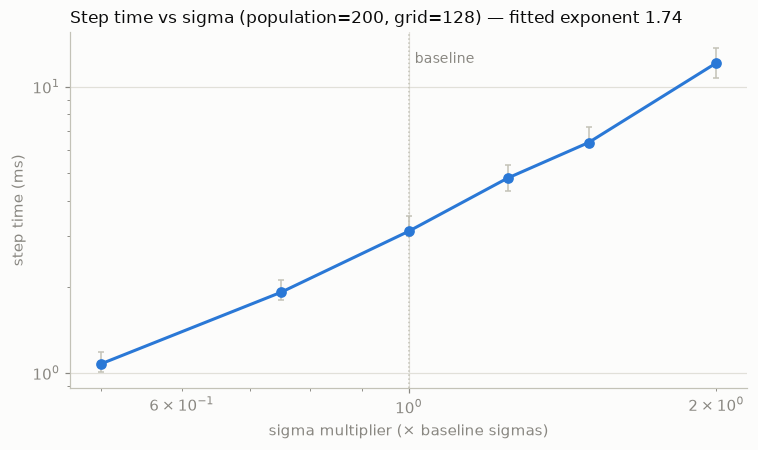

x0.5: 2283 total cells splatted per bird
x1.0: 8331 total cells splatted per bird
x2.0: 32419 total cells splatted per bird


In [6]:
multipliers = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0])


def scaled_config(m):
    cfg = dict(BASE)
    for key in ("sigma", "cohesion_sigma", "alignment_sigma"):
        cfg[key] = float(BASE[key] * m)
    return cfg


s_med, s_lo, s_hi = sweep_update_step(multipliers, config=scaled_config)

fig, ax = scaling_plot(
    multipliers, s_med, s_lo, s_hi,
    xlabel="sigma multiplier (× baseline sigmas)",
    title=f"Step time vs sigma (population={BASE_POPULATION}, grid={BASE_GRID})",
    exponent=fit_exponent(multipliers, s_med),
    budget_line=False,
)
ax.axvline(1.0, color=AXIS, linewidth=1, linestyle=":")
ax.annotate("baseline", (1.0, s_med.max()), textcoords="offset points",
            xytext=(4, 0), fontsize=9, color=MUTED)
plt.show()

for m in (0.5, 1.0, 2.0):
    cells_per_bird = sum(
        (2 * default_kernel_radius(float(BASE[k] * m), BASE_GRID) + 1) ** 2
        for k in ("sigma", "cohesion_sigma", "alignment_sigma"))
    print(f"x{m}: {cells_per_bird} total cells splatted per bird")